In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from datetime import datetime

In [2]:
dat = pd.read_csv('hids_exec_log.csv')
dat['timestamp'] = pd.to_datetime(dat['timestamp'], unit='s')
dat.head(3)

,timestamp,pid,ppid,process_name,event_type,event_name,severity,detail
0,2026-02-27 12:27:25.676109314,9698,5481,Isolated Web Co,8,mmap_rwx,HIGH,prot=READ|WRITE|EXEC
1,2026-02-27 12:27:26.179456949,19456,3880,konsole,4,open_sensitive,HIGH,/etc/passwd
2,2026-02-27 12:27:26.179704905,19456,3880,konsole,4,open_sensitive,HIGH,/etc/passwd


In [3]:
pid_features = []

for (pid, proc_name), group in dat.groupby(['pid', 'process_name']):
    group = group.sort_values('timestamp')
    
    # Duration
    if len(group) > 1:
        duration = (group['timestamp'].max() - group['timestamp'].min()).total_seconds()
    else:
        duration = 0.1
    
    # Event type distribution
    event_counts = group['event_type'].value_counts()
    total = len(group)
    
    features = {
        'pid': pid,
        'process_name': proc_name,
        'total_events': total,
        'duration_sec': duration,
        'event_rate': total / duration if duration > 0 else total,
        
        'high_sev_count': (group['severity'] == 'HIGH').sum(),
        'med_sev_count': (group['severity'] == 'MED').sum(),
        
        'execve_count': event_counts.get(1, 0),
        'fork_count': event_counts.get(2, 0),
        'ptrace_count': event_counts.get(3, 0),
        'open_sensitive_count': event_counts.get(4, 0),
        'connect_count': event_counts.get(5, 0),
        'setuid_count': event_counts.get(6, 0),
        'chmod_count': event_counts.get(7, 0),
        'mmap_rwx_count': event_counts.get(8, 0),
        'unlink_count': event_counts.get(9, 0),
        'rename_count': event_counts.get(10, 0),
        'bind_count': event_counts.get(11, 0),
        'process_vm_count': event_counts.get(12, 0),
        
        'network_ops': event_counts.get(5, 0) + event_counts.get(11, 0),
        'file_ops': (event_counts.get(4, 0) + event_counts.get(7, 0) + 
                     event_counts.get(9, 0) + event_counts.get(10, 0)),
    }
    
    features['baseline_score'] = (features['high_sev_count'] * 3) + (features['med_sev_count'] * 1)
    features['baseline_binary'] = 'Anomaly!' if features['baseline_score'] > 5 else 'Normal!'
    
    pid_features.append(features)

pid_df = pd.DataFrame(pid_features)

print(f"   Unique processes: {pid_df['process_name'].nunique()}")
print(pid_df[['pid', 'process_name', 'total_events', 'high_sev_count', 'baseline_score']].head(10).to_string())

   Unique processes: 63
    pid     process_name  total_events  high_sev_count  baseline_score
0     1          systemd             1               0               1
1  3023  systemd-journal             1               0               1
2  3054  systemd-userdbd             2               0               2
3  3291  systemd-resolve            11               0              11
4  3344          chronyd             1               0               1
5  3350          polkitd            44              32             108
6  3570   NetworkManager             1               0               1
7  3880          systemd             4               0               4
8  4202     kwin_wayland             5               5              15
9  4423  krunner_bookmar            10              10              30


In [4]:
def pid_fuzzy_score(row):
    score = 0
    
    # Factor 1: High severity events 
    score += min(row['high_sev_count'] * 8, 40)
    
    # Factor 2: Suspicious operations
    if row['ptrace_count'] > 0:
        score += 15
    if row['mmap_rwx_count'] > 0:
        score += 10
    if row['setuid_count'] > 0:
        score += 15
    if row['process_vm_count'] > 0:
        score += 20
    
    # Factor 3: Network activity 
    score += min(row['network_ops'] * 2, 20)
    
    # Factor 4: File operations 
    score += min(row['file_ops'], 10)
    
    # Factor 5: Process name based 
    if 'web' in str(row['process_name']).lower() and row['mmap_rwx_count'] > 0:
        score -= 5  # Browser is normal
    
    return min(max(round(score), 0), 100)  # Clamp 0-100

pid_df['fuzzy_score'] = pid_df.apply(pid_fuzzy_score, axis=1)
pid_df['risk_level'] = pd.cut(pid_df['fuzzy_score'], 
                              bins=[0, 20, 40, 60, 100],
                              labels=['Low', 'Medium', 'High', 'Critical'])

print(f"Fuzzy scores calculated (0-100 per PID)")
print("\nDistribution by risk level:")
print(pid_df['risk_level'].value_counts())

# Show high risk PIDs
print("\n High-risk PIDs (>60):")
high_risk = pid_df[pid_df['fuzzy_score'] > 60].sort_values('fuzzy_score', ascending=False)
for _, row in high_risk.iterrows():
    print(f"PID {int(row['pid']):7} | {row['process_name']:20} | Score: {row['fuzzy_score']:3} | High Sev: {row['high_sev_count']}")

Fuzzy scores calculated (0-100 per PID)

Distribution by risk level:
risk_level
Low         157
High         30
Medium       13
Critical      1
Name: count, dtype: int64

 High-risk PIDs (>60):
PID   28430 | ping                 | Score:  69 | High Sev: 11


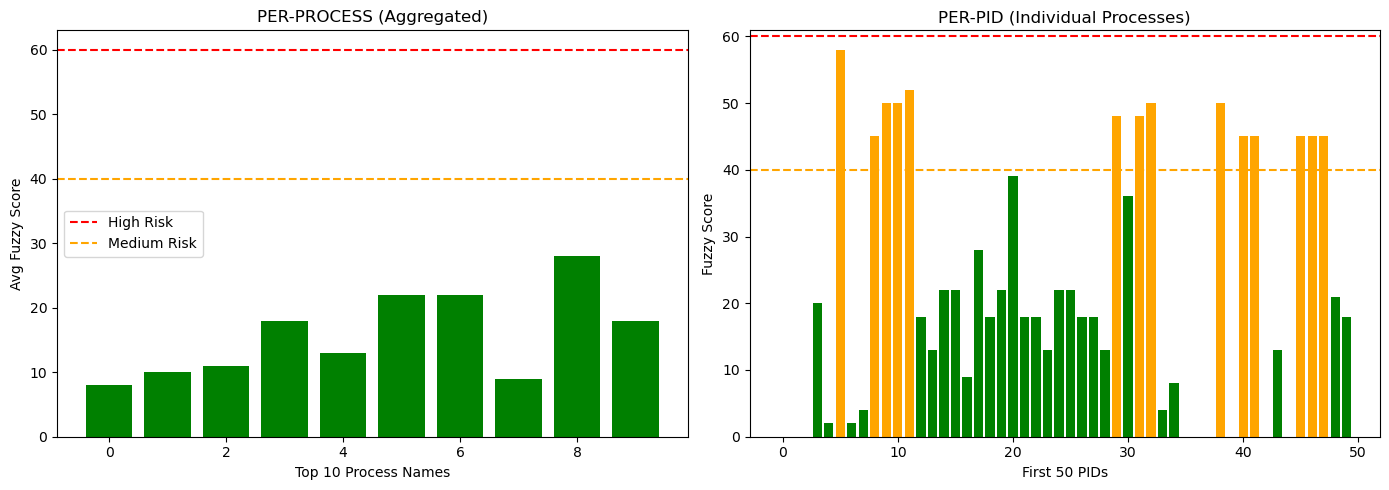


 Same process name, different PIDs have different risk levels!
   Per-PID features capture this nuance. Per-process loses it.


In [5]:

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Per-process (aggregated)
proc_agg = pid_df.groupby('process_name').agg({
    'fuzzy_score': 'mean',
    'pid': 'count'
}).reset_index()
colors1 = ['red' if x > 60 else 'orange' if x > 40 else 'green' for x in proc_agg['fuzzy_score']]
ax1.bar(range(min(10, len(proc_agg))), proc_agg['fuzzy_score'].head(10), color=colors1[:10])
ax1.set_title('PER-PROCESS (Aggregated)')
ax1.set_xlabel('Top 10 Process Names')
ax1.set_ylabel('Avg Fuzzy Score')
ax1.axhline(y=60, color='red', linestyle='--', label='High Risk')
ax1.axhline(y=40, color='orange', linestyle='--', label='Medium Risk')
ax1.legend()

# Per-PID (individual)
colors2 = ['red' if x > 60 else 'orange' if x > 40 else 'green' for x in pid_df['fuzzy_score'].head(50)]
ax2.bar(range(min(50, len(pid_df))), pid_df['fuzzy_score'].head(50), color=colors2)
ax2.set_title('PER-PID (Individual Processes)')
ax2.set_xlabel('First 50 PIDs')
ax2.set_ylabel('Fuzzy Score')
ax2.axhline(y=60, color='red', linestyle='--')
ax2.axhline(y=40, color='orange', linestyle='--')

plt.tight_layout()
plt.show()

print("\n Same process name, different PIDs have different risk levels!")
print("   Per-PID features capture this nuance. Per-process loses it.")

In [6]:
# First, let's understand our data imbalance
print("\n ORIGINAL DATA DISTRIBUTION:")
print(pid_df['risk_level'].value_counts())

# Create balanced training data by oversampling rare classes
low_risk = pid_df[pid_df['risk_level'] == 'Low']
medium_risk = pid_df[pid_df['risk_level'] == 'Medium']
high_risk = pid_df[pid_df['risk_level'] == 'High']
critical_risk = pid_df[pid_df['risk_level'] == 'Critical']

# Oversample minority classes to match the largest (or to a reasonable number)
target_count = len(low_risk)  # Use low risk as base

# For training, we'll use ALL data but with different weights
# But for actual training, we need to present balanced batches
# Since we're doing episodic training, we'll create a balanced dataset

# Create balanced dataset by oversampling minority classes
balanced_dfs = []

# Keep all low risk (they're majority)
balanced_dfs.append(low_risk)

# Oversample medium risk (repeat to match ~half of low risk)
if len(medium_risk) > 0:
    repeats = max(1, target_count // len(medium_risk))
    for i in range(repeats):
        balanced_dfs.append(medium_risk)

# Oversample high risk
if len(high_risk) > 0:
    repeats = max(1, target_count // len(high_risk))
    for i in range(repeats):
        balanced_dfs.append(high_risk)

# Oversample critical risk (the most important!)
if len(critical_risk) > 0:
    # Critical risk is extremely important - repeat many times
    repeats = max(10, target_count // len(critical_risk))
    for i in range(repeats):
        balanced_dfs.append(critical_risk)

# Combine all
balanced_pid_df = pd.concat(balanced_dfs, ignore_index=True)

class BalancedHIDSEnv:    
    def __init__(self, pid_data, use_all_data=False):
        """   use_all_data=True: for final testing (use original distribution)
        use_all_data=False: for training (use balanced distribution)
        """
        if use_all_data:
            self.data = pid_data.reset_index(drop=True)
        else:
            self.data = balanced_pid_df.reset_index(drop=True)
            
        self.current = 0
        self.max_steps = len(self.data)
        self.use_all_data = use_all_data
        
    def reset(self):
        self.current = 0
        return self._get_state()
    
    def _get_state(self):
        """State based on PER-PID features"""
        if self.current >= self.max_steps:
            return np.zeros(5, dtype=np.float32)
        
        row = self.data.iloc[self.current]
        return np.array([
            row['fuzzy_score'] / 100,           # Normalized risk (0-1)
            min(row['high_sev_count'] / 10, 1.0), # High severity density
            min(row['mmap_rwx_count'] / 3, 1.0),  # Suspicious ops
            min(row['network_ops'] / 10, 1.0),    # Network activity
            self.current / self.max_steps         # Progress
        ], dtype=np.float32)
    
    def step(self, action):
        if self.current >= self.max_steps:
            return np.zeros(5, dtype=np.float32), 0, True
            
        row = self.data.iloc[self.current]
        fuzzy = row['fuzzy_score']
        
        # Heavily penalize false alerts on low-risk
        if fuzzy < 20:  # LOW RISK
            if action == 0:      # Ignore
                reward = 10
            elif action == 1:    # Log (acceptable but not optimal)
                reward = 5
            else:                 # Alert or Block (BAD - false positive)
                reward = -20
        
        elif fuzzy < 40:  # MEDIUM RISK
            if action == 1:      # Log
                reward = 10
            elif action == 2:    # Alert (acceptable)
                reward = 5
            elif action == 0:    # Ignore (under-reacting)
                reward = -5
            else:                 # Block (over-reacting)
                reward = -10
        
        elif fuzzy < 60:  # HIGH RISK
            if action == 2:      # Alert
                reward = 10
            elif action == 3:    # Block (good for critical)
                reward = 8
            elif action == 1:    # Log (under-reacting)
                reward = 0
            else:                 # Ignore (very bad)
                reward = -15
        
        else:  # CRITICAL RISK (fuzzy >= 60)
            if action == 3:      # Block
                reward = 20       # Extra reward for catching critical
            elif action == 2:    # Alert (acceptable but not optimal)
                reward = 10
            else:                 # Ignore/Log (very bad)
                reward = -25
        
        self.current += 1
        done = self.current >= self.max_steps
        
        return self._get_state(), reward, done

# Test environment
train_env = BalancedHIDSEnv(pid_df, use_all_data=False)
test_env = BalancedHIDSEnv(pid_df, use_all_data=True)

print(f"\nTraining environment: {len(train_env.data)} PIDs (balanced)")
print(f" Testing environment: {len(test_env.data)} PIDs (original)")


 ORIGINAL DATA DISTRIBUTION:
risk_level
Low         157
High         30
Medium       13
Critical      1
Name: count, dtype: int64

Training environment: 620 PIDs (balanced)
 Testing environment: 268 PIDs (original)


In [7]:
# Q-table: 10 risk levels × 4 actions
Q = np.zeros((10, 4))

# Better parameters
alpha = 0.1      # Learning rate
gamma = 0.95     # Discount factor (higher = cares more about future)
epsilon = 0.3    # Start with more exploration

# Training metrics
episodes = 300   # More episodes
rewards_history = []
accuracy_history = []
precision_history = []
recall_history = []
f1_history = []

print("Training on BALANCED data...")
for episode in range(episodes):
    env = BalancedHIDSEnv(pid_df, use_all_data=False)  # Use balanced data for training
    state_cont = env.reset()
    total_reward = 0
    correct_actions = 0
    total_actions = 0
    
    # For precision/recall
    true_pos = false_pos = true_neg = false_neg = 0
    
    done = False
    
    while not done:
        # Discretize state based on fuzzy score
        state_idx = int(state_cont[0] * 9)  # 0-9
        state_idx = min(state_idx, 9)  # Ensure within bounds
        
        # Epsilon-greedy with decay
        if random.random() < epsilon:
            action = random.randint(0, 3)  # Explore
        else:
            action = np.argmax(Q[state_idx, :])  # Exploit
        
        # Take action
        next_state_cont, reward, done = env.step(action)
        next_state_idx = int(next_state_cont[0] * 9)
        next_state_idx = min(next_state_idx, 9)
        
        # Get current process data
        current_idx = env.current - 1  # -1 because already incremented
        if current_idx >= 0:
            row = env.data.iloc[current_idx]
            fuzzy = row['fuzzy_score']
            
            # Determine correct action based on fuzzy score
            if fuzzy < 20:
                correct_action = 0
            elif fuzzy < 40:
                correct_action = 1
            elif fuzzy < 60:
                correct_action = 2
            else:
                correct_action = 3
            
            if action == correct_action:
                correct_actions += 1
            
            # For precision/recall (treat actions 2-3 as "positive")
            should_alert = fuzzy >= 40
            did_alert = action >= 2
            
            if should_alert and did_alert:
                true_pos += 1
            elif should_alert and not did_alert:
                false_neg += 1
            elif not should_alert and did_alert:
                false_pos += 1
            else:
                true_neg += 1
        
        # Q-learning update
        Q[state_idx, action] = Q[state_idx, action] + alpha * (
            reward + gamma * np.max(Q[next_state_idx, :]) - Q[state_idx, action]
        )
        
        total_reward += reward
        total_actions += 1
        state_cont = next_state_cont
    
    # Decay epsilon
    epsilon = max(0.01, epsilon * 0.995)
    
    # Calculate metrics
    accuracy = correct_actions / max(total_actions, 1) * 100
    precision = true_pos / max(true_pos + false_pos, 1) * 100
    recall = true_pos / max(true_pos + false_neg, 1) * 100
    f1 = 2 * (precision * recall) / max(precision + recall, 1) if (precision + recall) > 0 else 0
    
    rewards_history.append(total_reward)
    accuracy_history.append(accuracy)
    precision_history.append(precision)
    recall_history.append(recall)
    f1_history.append(f1)
    
    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1}: Acc={accuracy:.1f}%, Prec={precision:.1f}%, Rec={recall:.1f}%, F1={f1:.1f}%")

print("\n Final Q-table (Risk Level × Actions):")
print(pd.DataFrame(Q.round(2), columns=['Ignore', 'Log', 'Alert', 'Block']))

Training on BALANCED data...
Episode 50: Acc=73.2%, Prec=90.0%, Rec=87.6%, F1=88.8%
Episode 100: Acc=71.1%, Prec=90.5%, Rec=93.2%, F1=91.8%
Episode 150: Acc=82.7%, Prec=91.9%, Rec=89.3%, F1=90.6%
Episode 200: Acc=85.3%, Prec=93.8%, Rec=93.2%, F1=93.5%
Episode 250: Acc=86.0%, Prec=96.9%, Rec=92.8%, F1=94.8%
Episode 300: Acc=88.5%, Prec=97.7%, Rec=94.8%, F1=96.2%

 Final Q-table (Risk Level × Actions):
   Ignore     Log   Alert   Block
0  196.42  192.00  166.64  166.59
1  181.39  196.07  186.36  174.07
2  181.70  196.86  190.86  175.65
3  180.79  195.49  195.33  183.40
4  181.71  198.57  218.03  200.10
5  178.94  193.12  201.73  203.82
6  331.42  334.52  365.08  366.27
7    0.00    0.00    0.00    0.00
8    0.00    0.00    0.00    0.00
9    0.00    0.00    0.00    0.00


In [8]:
#result 
# Test the trained policy on ALL data
env = BalancedHIDSEnv(pid_df, use_all_data=True)
state_cont = env.reset()
done = False
results = []

while not done:
    state_idx = int(state_cont[0] * 9)
    state_idx = min(state_idx, 9)
    action = np.argmax(Q[state_idx, :])
    
    row = env.data.iloc[env.current]
    fuzzy = row['fuzzy_score']
    
    # Determine risk level
    if fuzzy < 20:
        risk = "Low"
        expected = "Ignore"
    elif fuzzy < 40:
        risk = "Medium"
        expected = "Log"
    elif fuzzy < 60:
        risk = "High"
        expected = "Alert"
    else:
        risk = "Critical"
        expected = "Block"
    
    # Map action to text
    actions = ["Ignore", "Log", "Alert", "Block"]
    rl_action = actions[action]
    
    # Confidence score
    confidence = Q[state_idx, action] / Q[state_idx, :].max() * 100
    
    results.append({
        'pid': int(row['pid']),
        'process': row['process_name'],
        'risk_level': risk,
        'fuzzy_score': fuzzy,
        'rl_action': rl_action,
        'expected_action': expected,
        'correct': rl_action == expected,
        'confidence': round(confidence, 1),
        'baseline': row['baseline_binary']
    })
    
    next_state_cont, _, done = env.step(action)
    state_cont = next_state_cont

# Create DataFrame
results_df = pd.DataFrame(results)

# Calculate metrics
total = len(results_df)
correct = results_df['correct'].sum()
accuracy = correct / total * 100

# Calculate precision and recall 
results_df['is_threat'] = results_df['risk_level'].isin(['High', 'Critical'])
results_df['detected'] = results_df['rl_action'].isin(['Alert', 'Block'])

true_pos = ((results_df['is_threat']) & (results_df['detected'])).sum()
false_pos = ((~results_df['is_threat']) & (results_df['detected'])).sum()
false_neg = ((results_df['is_threat']) & (~results_df['detected'])).sum()

precision = true_pos / (true_pos + false_pos) * 100 if (true_pos + false_pos) > 0 else 0
recall = true_pos / (true_pos + false_neg) * 100 if (true_pos + false_neg) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\nRL Performance matrics")
print("-" * 40)
print(f"Total PIDs Analyzed:    {total}")
print(f"Correct Decisions:      {correct}")
print(f"Accuracy:               {accuracy:.1f}%")
print(f"Precision:              {precision:.1f}%")
print(f"Recall:                 {recall:.1f}%")
print(f"F1-Score:               {f1:.1f}%")

risk_counts = results_df['risk_level'].value_counts()
for risk in ['Low', 'Medium', 'High', 'Critical']:
    count = risk_counts.get(risk, 0)
    pct = count/total*100
    print(f"{risk:8}: {count:3} PIDs ({pct:.1f}%)")

print("\nClassify Actions: ")
print("-" * 40)
action_counts = results_df['rl_action'].value_counts()
for action in ['Ignore', 'Log', 'Alert', 'Block']:
    count = action_counts.get(action, 0)
    pct = count/total*100
    print(f"{action:8}: {count:3} ({pct:.1f}%)")

print("\nResults in: hids_final_results.csv")
results_df.to_csv('hids_final_results.csv', index=False)


RL Performance matrics
----------------------------------------
Total PIDs Analyzed:    268
Correct Decisions:      247
Accuracy:               92.2%
Precision:              100.0%
Recall:                 93.5%
F1-Score:               96.7%
Low     : 223 PIDs (83.2%)
Medium  :  14 PIDs (5.2%)
High    :  29 PIDs (10.8%)
Critical:   2 PIDs (0.7%)

Classify Actions: 
----------------------------------------
Ignore  : 209 (78.0%)
Log     :  30 (11.2%)
Alert   :  22 (8.2%)
Block   :   7 (2.6%)

Results in: hids_final_results.csv
